In [1]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import networkx as nx
import cvxpy as cp
from collections import Counter, defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.cluster import DBSCAN
import networkx as nx
from tabulate import tabulate

# Build Class and function

In [ ]:
class Portfolio:
    """
    Portfolio construction toolkit centered on mesoscopic filtering.

    This class supports:
    - Data ingestion from Yahoo Finance
    - Return computation and date/symbol/sector alignment
    - Mesoscopic filtering of the correlation matrix (RMT + market-mode removal)
    - Community detection on the mesoscopic layer
    - GMV optimization either at the asset level or at the community level
    - Stability visualization of risk fractions (noise / market / meso)
    """
    def __init__(self, data_csv, start="2000-01-01", end="2024-12-31", price_data=None, returns = None):
        """
        Parameters
        ----------
        data_csv : pandas.DataFrame
            Must contain at least columns ['Symbol', 'Sector'].
        start, end : str
            Date boundaries for historical price download, if needed.
        price_data : pandas.DataFrame or None
            Optional preloaded price dataframe (Adj Close, columns=Symbols).
        returns : pandas.DataFrame or None
            Optional precomputed returns (index=dates, columns=Symbols).
        """

        self.data_csv = data_csv
        self.symbols = self.data_csv['Symbol']
        self.sector = self.data_csv['Sector']
        self.start = start
        self.end = end
        self.price_data = price_data
        self.returns = returns
        self.dates = None
        self.C_g = None  # mesoscopic correlation matrix
        self.D = None  # diagonal matrix of asset volatilities (std dev)
        self.cov_g = None # mesoscopic covariance matrix
        self.communities = None # list of community labels, length = n_assets
        self.weight = None

    def get_data_yahoo(self, save = False, path = None, no_nan = True):
        """
        Download adjusted close prices from Yahoo Finance for symbols in `self.symbols`.

        Parameters
        ----------
        save : bool
            If True, writes the downloaded price_data to CSV at `path`.
        path : str or None
            Destination path for CSV saving.
        no_nan : bool
            If True, drops assets (columns) with any missing values.
        """
        # Download Adjusted Close prices
        self.price_data = yf.download(self.symbols.to_list(), self.start , self.end, auto_adjust=False)['Adj Close']
         # Optionally remove columns with NaNs
        if no_nan:
            self.price_data.dropna(axis=1, inplace = True)
        
        # Optionally save
        if save:
            if path is None:
                raise ValueError("Path must be specified if save is True.")
            self.price_data.to_csv(path)


    def _evaluate_cov_g(self):
        """
        Build mesoscopic covariance matrix from mesoscopic correlations.

        Returns
        -------
        numpy.ndarray
            Mesoscopic covariance matrix.
        """
        self.D = np.diag(self.returns.std().values)

        # Covariance in the mesoscopic subspace
        self.cov_g = self.D @ self.C_g @ self.D 
        return self.cov_g
    
    def compute_return(self):
        """
        Compute simple returns from `price_data` (if `returns` not already provided)
        Returns
        -------
        pandas.DataFrame
            Returns dataframe (index=dates, columns=Symbols).
        """
        if self.price_data is None and self.returns is None:
             raise ValueError("Price data not available, download or use a valid dataframe")
        elif self.returns is None:
            # Clean columns with NaNs and compute simple returns
            self.price_data.dropna(axis = 1, inplace = True)
            self.returns = self.price_data.pct_change().dropna()

        # Aligned to the returns         
        self.symbols =  self.returns.columns.to_list()
        self.dates = pd.to_datetime(self.returns .index)
        self.sector = self.data_csv[self.data_csv['Symbol'].isin(self.returns .columns)]['Sector'].to_list()
        return self.returns 

    def mesoscopic_filter(self):
        """
        Compute the mesoscopic correlation matrix C_g

        Steps
        -----
        1) Compute empirical correlation matrix.
        2) Eigen-decompose and identify:
            - λ_1 (largest) as market mode.
            - MP bulk upper edge λ_max with Laloux correction σ^2 = 1 - λ_1/N.
        3) Keep eigenmodes with λ in (λ_max, λ_1) → 'mesoscopic' band.
        4) Rebuild C_g from mesoscopic eigenpairs and compute cov_g.

        Returns
        -------
        numpy.ndarray
            Mesoscopic correlation matrix C_g (NxN).
        """
        if self.returns  is None:
            raise ValueError("No return, please before compute return")

        corr_matrix = self.returns.corr().values
        T, N = self.returns .shape

        # Eigen-decomposition of correlation matrix
        eigvals, eigvecs = np.linalg.eigh(corr_matrix)
        
        
        Q = T / N 
        lambda_max = (1 + 1 / np.sqrt(Q))**2  #MP upper limit
        lambda_1 = eigvals[-1] #isolate the biggest eigenvalue
        sigma2 = 1 - lambda_1 / N
        lambda_max = sigma2 * (1 + 1 / np.sqrt(Q))**2 #Laloux correction

        # Mesoscopic band
        meso_indices = np.where((eigvals > lambda_max) & (eigvals < lambda_1))[0]
        
        # Reconstruct C_g from mesoscopic
        C_g = np.zeros((N, N))
        for i in meso_indices:
            C_g += eigvals[i] * np.outer(eigvecs[:, i], eigvecs[:, i])
        self.C_g = C_g
        self.cov_g = self._evaluate_cov_g()
        return self.C_g



    @staticmethod   
    def _get_risk_fractions(returns_window):
        """
        Split total correlation 'risk' into noise / market / mesoscopic shares for a window.

        Parameters
        ----------
        returns_window : pandas.DataFrame
            Return series restricted to a rolling window.

        Returns
        -------
        dict
            Fractions of total spectral mass: {'noise', 'market', 'meso'}.
        """
        T, N = returns_window.shape
        corr = returns_window.corr().values

        eigvals, _ = np.linalg.eigh(corr)
        eigvals = np.sort(eigvals)
        
        Q = T / N
        lambda_1 = eigvals[-1]
        sigma2 = 1 - lambda_1 / N
        lambda_max = sigma2 * (1 + 1 / np.sqrt(Q))**2

        noise = eigvals[eigvals <= lambda_max]
        market = np.array([lambda_1])
        meso = eigvals[(eigvals > lambda_max) & (eigvals < lambda_1)]

        total_risk = np.sum(eigvals)
        
        return {
            "noise": np.sum(noise) / total_risk,
            "market": np.sum(market) / total_risk,
            "meso": np.sum(meso) / total_risk,
        }

    def plot_stability(self, windows_years = 2):
        """
        Plot the temporal stability of noise / market / mesoscopic risk fractions.

        Parameters
        ----------
        windows_years : int
            Size of each non-overlapping rolling window (in years).
        """
        if self.dates is None:
            raise ValueError("No date available, please run compute_return first")
        
        # Build non-overlapping windows of given length
        windows = []
        start = self.dates[0]

        while start + pd.DateOffset(years = windows_years) < self.dates[-1]:
            end = start + pd.DateOffset(years = windows_years)
            windows.append((start, end))
            start = end
        risks = []

        for start, end in windows:
            returns = np.exp(self.returns ) - 1
            returns.index = pd.to_datetime(returns.index)
            subset = returns[(returns.index >= start) & (returns.index < end)]
            risks.append(self._get_risk_fractions(subset))

        # Risk fractions by window
        risk_df = pd.DataFrame(risks)
        risk_df['window_start'] = [w[0] for w in windows]
        risk_df.set_index('window_start', inplace=True)

        # Std of differences quantifies temporal variability of each component
        diffs = risk_df.diff().dropna()
        std_noise = diffs['noise'].std()
        std_market = diffs['market'].std()
        std_meso = diffs['meso'].std()

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(risk_df.index, risk_df['noise'], label='Noise', color = "red", marker = 'o', linestyle = 'dashed')
        ax.plot(risk_df.index, risk_df['market'], label='Systemic', color = "blue", marker = 'o', linestyle = 'dashed')
        ax.plot(risk_df.index, risk_df['meso'], label='Mesoscopic', color = "green", marker = 'o', linestyle = 'dashed')

        
        ax.text(risk_df.index[3], risk_df['noise'].iloc[3], rf'$\sigma_r={std_noise:.3f}$', va='bottom', ha='left', size = 12,bbox=dict(facecolor='white', alpha=0.5))
        ax.text(risk_df.index[3], risk_df['market'].iloc[3], rf'$\sigma_s={std_market:.3f}$', va='bottom', ha='right', size = 12,bbox=dict(facecolor='white', alpha=0.5))
        ax.text(risk_df.index[3], risk_df['meso'].iloc[3], rf'$\sigma_g={std_meso:.3f}$', va='bottom', ha='left', size = 12,bbox=dict(facecolor='white', alpha=0.5))

        ax.set_title('Cumulative Risk Fractions over Time', size = 18)
        ax.set_ylabel('Fraction of Total Risk', size = 15)
        ax.set_xlabel('Start of 2-Year Window', size = 15)
        ax.tick_params(axis='both', which='major', labelsize=13) 
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        plt.show()

    @staticmethod
    def _commu_to_list(G, communities):
        """
        Convert a sequence of node-sets (communities) into a flat label list.

        Parameters
        ----------
        G : networkx.Graph
            Graph.
        communities : iterable of iterables
            Sequence of node sets produced by a community algorithm.
        Returns
        -------
        list[int]
            community_id for each node index in 0..N-1 (length N).
        """
        node_to_comm = {}
        for comm_id, nodes in enumerate(communities):
            for node in nodes:
                node_to_comm[node] = comm_id
        n_assets = len(G.nodes)
        communities = [node_to_comm[i] for i in range(n_assets)]
        return communities

    @staticmethod
    def kmeans_C_g(C_g, n_clusters):
        """
        Convert a sequence of node-sets (communities) into a flat label list.

        Parameters
        ----------
        G : networkx.Graph
            Graph whose nodes are expected to be indexed 0..N-1.
        communities : iterable of iterables
            Sequence of node sets produced by a community algorithm.

        Returns
        -------
        list[int]
            community_id for each node index in 0..N-1 (length N).
        """
        labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(C_g)
        return labels

    @staticmethod
    def DBSCAN_Cg(C_g, returns, eps=0.5, min_samples=5, metric='precomputed'):
        """
        DBSCAN over correlation distances induced by mesoscopic projection.

        Parameters
        ----------
        C_g : numpy.ndarray
        returns : pandas.DataFrame
        eps, min_samples, metric : DBSCAN parameters

        Returns
        -------
        numpy.ndarray
            Cluster labels for each asset.
        """
        X = (returns @ C_g).T 
        dist = pairwise_distances(X, metric='correlation')
        labels = DBSCAN(eps=0.3, min_samples=3, metric='precomputed').fit_predict(dist)
        return labels
    
    @staticmethod
    def sector_to_label(list_sector):
        """
        Map sector names to integer labels.

        Parameters
        ----------
        list_sector : list[str]
            Sector for each asset in symbol order.

        Returns
        -------
        list[int]
            Integer labels corresponding to sector categories.
        """
        sector_to_number = {sector: i for i, sector in enumerate(set(list_sector))}
        
        
        mapped_sectors = [sector_to_number[sector] for sector in list_sector]
        
        return mapped_sectors

    def community_discover(self, algo = "Louvain", seed = 42, **kwargs):
        """
        Detect communities from C_g using different algorithms.

        Parameters
        ----------
        algo : {'Louvain','Label','Kmean','DBSCAN','Sector'}
            - Louvain / Label: graph-based community detection.
            - Kmean: KMeans.
            - DBSCAN: density clustering on correlation distances after meso projection.
            - Sector: use provided sector labels as communities.
        seed : int
            Random seed.
        kwargs : dict
            Extra parameters per algorithm, e.g. n_clusters, eps, min_samples, metric.

        Returns
        -------
        list[int]
            Community label per asset.
        """
        if self.C_g is None:
            raise ValueError("No Mesoscopic structure found, please run mesoscopic_filter")
        
        # Build weighted graph from mesoscopic correlations
        G = nx.from_numpy_array(self.C_g)

        if algo == "Louvain":
            communities = nx.community.louvain_communities(G, seed=seed, weight='weight')
            self.communities = self._commu_to_list(G, communities)

        elif algo == "Label":
                    communities = list(nx.community.fast_label_propagation_communities(G, weight='weight',seed = seed))
                    self.communities = self._commu_to_list(G, communities)

        elif algo == "Kmean":
                    n_clusters = kwargs.get("n_clusters", 5)
                    self.communities = self.kmeans_C_g(self.C_g, n_clusters)

        elif algo == "DBSCAN":
                    min_samples = kwargs.get("min_samples", 20)
                    eps = kwargs.get("eps", 0.5)
                    metric = kwargs.get("metric", "precomputed")
                    self.communities = self.DBSCAN_Cg(returns = self.returns, C_g = self.C_g, eps = eps, min_samples = min_samples, metric = metric)

        elif algo == "Sector":
             self.communities = self.sector_to_label(self.sector)

        else:
            raise ValueError("Select correct algorithm for community discover")

        
        return self.communities

    def plot_communities_pie(self, title = 'Louvain'):
        """
        Visualize sector composition within each discovered community (pie charts grid).

        Parameters
        ----------
        title : str
            Title suffix indicating the community detection algorithm used.
        """
        if self.communities is None:
            raise ValueError("No communities found, please run community_discover")
        
         # Build mapping: community_id -> list of sector labels in that community
        comm2sectors = defaultdict(list)
        for asset_idx, comm_id in enumerate(self.communities):
            comm2sectors[comm_id].append(self.sector[asset_idx])

        # Palette per sector (in our case sectors are  10)
        sector_labels = sorted(set(self.sector)) 
        colors = [
            '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
        ]
        sector_color_dict = dict(zip(sector_labels, colors))

        # Layout grid: up to 3 columns
        n_communities = len(comm2sectors)
        n_cols = min(n_communities, 3)
        n_rows = (n_communities + n_cols - 1) // n_cols

        fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
        axs = axs.flatten() if n_communities > 1 else [axs]

        num_com = 1
        for i, (comm_id, sectors) in enumerate(comm2sectors.items()):
            ax = axs[i]
            count = Counter(sectors)

            # Sizes normalized to 1 for percentage labels
            sizes = [count.get(s, 0) for s in sector_labels]
            total = sum(sizes)
            sizes = [s / total for s in sizes] if total > 0 else [0] * len(sizes)

            # Explode: more readaility
            explode = [0.05 if s > 0.15 else 0 for s in sizes]

            wedges, texts, autotexts = ax.pie(
                sizes,
                colors=[sector_color_dict[s] for s in sector_labels],
                startangle=90,
                wedgeprops=dict(edgecolor='white'),
                autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
                pctdistance=0.8,
                labeldistance=1.1,
                explode=explode
            )

            for text in autotexts:
                text.set_fontsize(12)
                text.set_horizontalalignment('center')
                text.set_verticalalignment('center')
                text.set_weight('bold')

            ax.set_title(f"Community {num_com}", fontsize=14)
            num_com += 1
            ax.axis('equal') # Equal aspect ratio ensures a perfect circle
            
        fig.suptitle(f"Community Searching Algorithm {title}", fontsize = 18)

        # Hide any unused subplots
        for j in range(i + 1, len(axs)):
            axs[j].axis('off')

       # Global legend 
        fig.legend(
            handles=[plt.Line2D([0], [0], marker='o', color='w', label=lab,
                                markerfacecolor=sector_color_dict[lab], markersize=10)
                    for lab in sector_labels],
            loc='lower center',
            ncol=min(len(sector_labels), 5),
            bbox_to_anchor=(0.5, -0.05),
            title = 'Sector',
            title_fontsize=14,
            fontsize=12
        )
        plt.tight_layout()
        plt.show()

    @staticmethod
    def solve_gmv(cov_g, short = False):
        """
        Solve standard GMV: (optionally w>=0).

        Parameters
        ----------
        cov_g : numpy.ndarray
            Covariance matrix (can be mesoscopic or empirical).
        short : bool
            If False, impose long-only (w >= 0).

        Returns
        -------
        numpy.ndarray
            Optimal asset weights.
        """
        N = cov_g.shape[0]
        w = cp.Variable(N)
        objective = cp.Minimize(cp.quad_form(w, cov_g))
        if short:
            constraints = [cp.sum(w) == 1]
        else:
            constraints = [cp.sum(w) == 1,  w >= 0 ]
        problem = cp.Problem(objective, constraints)
        problem.solve()
        return w.value

    @staticmethod
    def solve_gmv_community(cov_g, community_labels, short=False):
        """
        Solve community-level GMV with homogeneous weights within communities.

        Pipeline
        --------
        1) Aggregate asset-level Σ into community-level Σ_c (average within/between blocks).
        2) Solve GMV for community weights W (sum to 1, optionally long-only).
        3) Distribute each community's weight equally across its member assets.

        Parameters
        ----------
        cov_g : numpy.ndarray
            Covariance matrix at asset level.
        community_labels : list[int]
            Community label per asset.
        short : bool
            If False, impose W >= 0 (long-only at community level).

        Returns
        -------
        numpy.ndarray
            Asset-level weights consistent with equal-within-community allocation.
        """
        N = len(community_labels)
        
        # Build community index map: community_id -> list of member asset indices
        community_map = defaultdict(list)
        for idx, c_id in enumerate(community_labels):
            community_map[c_id].append(idx)

        community_list = list(community_map.values())
        n = len(community_list)

        # Community-level covariance
        # diagonal: avg within-community
        # off-diagonals: avg cross-community covariances
        Sigma_c = np.zeros((n, n))

        for c in range(n):
            assets_c = community_list[c]
            Nc = len(assets_c)

            var_c = np.mean([cov_g[i, i] for i in assets_c])
            cov_c = np.mean([cov_g[i, j] for i in assets_c for j in assets_c if i != j]) if Nc > 1 else 0
            Sigma_c[c, c] = var_c + (Nc - 1) * cov_c

            for k in range(c + 1, n):
                assets_k = community_list[k]
                cross_cov = np.mean([cov_g[i, j] for i in assets_c for j in assets_k])
                Sigma_c[c, k] = Sigma_c[k, c] = cross_cov

        # Solve GMV at the community level
        W = cp.Variable(n)
        objective = cp.Minimize(cp.quad_form(W, Sigma_c))
        if short:
            constraints = [cp.sum(W) == 1]
        else:
            constraints = [cp.sum(W) == 1,  W >= 0 ]
        prob = cp.Problem(objective, constraints)
        prob.solve()

        # Expand community weights equally to member assets
        weights = np.zeros(N)
        for c, Wc in enumerate(W.value):
            assets_c = community_list[c]
            Nc = len(assets_c)
            for i in assets_c:
                weights[i] = Wc / Nc

        return weights

    def portfolio_building(self, seed = 42,**kwargs ):
        """
        End-to-end portfolio builder.

        Options (kwargs)
        ----------------
        community : bool (default=True)
            If True: mesoscopic filter + community detection + community GMV.
        is_equal : bool (default=False)
            If True: build equally-weighted portfolio (mutually exclusive with `community=True`).
        short : bool (default=False)
            If True: allow short-selling (remove non-negativity constraints).
        algo : str (default='Louvain')
            Community detection algorithm ('Louvain','Label','Kmean','DBSCAN','Sector').
        seed, min_samples, eps, metric :
            Extra parameters passed to community detection when applicable.

        Returns
        -------
        numpy.ndarray
            Final asset weights.
        """
        use_community = kwargs.get("community", True)
        is_equal = kwargs.get("is_equal", False)
        if is_equal and use_community:
             raise ValueError("use_community and is_equal cannot be True at same time ")
        short = kwargs.get("short", False)
        algo = kwargs.get("algo", "Louvain")
        seed = kwargs.get("seed", 42)
        min_samples = kwargs.get("min_samples", 5)
        eps = kwargs.get("eps", 0.5)
        metric = kwargs.get("metric", "precomputed")
        self.compute_return()
        if use_community:
            self.mesoscopic_filter()
            algo = kwargs.pop("algo", "Louvain")
            self.communities = self.community_discover(algo = algo, seed = seed, **kwargs)
            self.w = self.solve_gmv_community(self.cov_g,self.communities, short = short)
        elif is_equal:
             self.w = np.ones(len(self.returns.columns)) * 1 / len(self.returns.columns)
        else:
            self.cov_g = self.returns.cov().values 
            self.w = self.solve_gmv(self.cov_g, short)
        return self.w

## Collect and Download Data

In [14]:
data_csv = pd.read_csv('data/SandP500.csv')
data_csv.sort_values(by='Symbol', inplace = True)

### Download (If you already have dataset, you can skip it)

In [9]:
portfolio = Portfolio(data_csv)
portfolio.get_data_yahoo(save = True, path = "data\\price_data.csv", no_nan = True)

[*********************100%***********************]  496 of 496 completed

104 Failed downloads:
['CHK', 'YHOO', 'MON', 'PXD', 'FLIR', 'BBT', 'GPS', 'JEC', 'ABC', 'VIAB', 'NBL', 'PKI', 'BBBY', 'DO', 'MYL', 'ALXN', 'XL', 'XEC', 'KSU', 'LLL', 'MRO', 'APC', 'BLL', 'FISV', 'FTR', 'AGN', 'DNR', 'SWN', 'PDCO', 'ADS', 'SYMC', 'CTL', 'PBCT', 'ALTR', 'RHT', 'LM', 'HRS', 'XLNX', 'UTX', 'VAR', 'ETFC', 'HCP', 'CTXS', 'CBS', 'AVP', 'DTV', 'QEP', 'TSS', 'CELG', 'ESV', 'WIN', 'CERN', 'DLPH', 'TIF', 'TMK', 'DISCA', 'RTN', 'DFS']: YFTzMissingError('possibly delisted; no timezone found')
['WLP', 'MJN', 'SWY', 'STJ', 'TSO', 'CAM', 'SIAL', 'BRCM', 'SPLS', 'GGP', 'WAG', 'BCR', 'HSP', 'MHFI', 'FDO', 'MWV', 'KORS', 'CBG', 'COH', 'DPS', 'HCN', 'POM', 'WYN', 'SNI', 'PCLN', 'ARG', 'CFN', 'RAI', 'HCBK', 'WFM', 'LLTC', 'CVC', 'LUK', 'ZMH', 'GMCR', 'KRFT', 'LO', 'TWC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-31)')
['COG', 'MNK', 'JWN', 'SRCL', 'NLSN']: YFPricesMissin

### Prepare the Dataset

In [24]:
price_data =  pd.read_csv('data/price_data.csv', index_col=0)
portfolio = Portfolio(data_csv, price_data = price_data)
portfolio.compute_return()

,A,AA,AAPL,ABT,ADBE,ADI,ADM,ADP,ADSK,AEE,...,WM,WMB,WMT,WY,XEL,XOM,XRAY,XRX,YUM,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,-0.076389,0.004633,-0.084310,-0.028572,-0.083889,-0.050589,-0.010417,0.000000,-0.048689,0.000000,...,-0.003597,-0.022177,-0.037418,-0.037568,0.023027,-0.019155,0.000000,-0.046511,-0.020101,-0.048423
2000-01-05,-0.062030,0.057648,0.014633,-0.001838,0.019771,0.014599,-0.015789,-0.009616,-0.062992,0.038684,...,0.003610,0.061856,-0.020407,0.052974,0.038586,0.054517,0.017287,0.051490,0.005128,-0.001184
2000-01-06,-0.038076,-0.013082,-0.086538,0.034990,0.008163,-0.027339,0.005347,0.013350,-0.060924,-0.003724,...,-0.007193,0.021360,0.010912,0.046779,-0.009288,0.051697,0.001307,-0.020619,-0.008503,0.014218
2000-01-07,0.083334,-0.002945,0.047369,0.010676,0.048583,0.028107,0.015958,0.022753,0.118568,0.014953,...,-0.039856,0.026615,0.075565,-0.032883,0.000000,-0.002935,-0.002611,0.023684,-0.022298,0.002337
2000-01-10,0.060576,-0.002955,-0.017588,-0.007042,0.038610,0.087050,0.000000,0.024591,-0.010099,-0.007366,...,0.003774,-0.018519,-0.018249,-0.004360,0.000000,-0.013981,0.023560,-0.023136,0.040351,-0.018065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.000669,0.019556,0.003065,0.000700,-0.000962,0.014685,-0.001585,0.000442,-0.002113,0.004480,...,-0.009862,0.010469,-0.020490,0.021091,0.004748,0.004062,0.013369,0.126341,0.011333,0.013229
2024-12-24,0.011144,0.000778,0.011478,0.003937,0.002686,0.014891,0.004364,0.007853,0.012572,0.013379,...,0.007753,0.010176,0.025789,0.006410,0.007236,0.000941,-0.002638,-0.023280,0.008516,0.010850
2024-12-26,-0.001984,-0.006734,0.003176,0.004444,0.004956,-0.000138,-0.000395,0.002597,-0.003154,-0.002200,...,-0.001753,-0.011722,0.001187,-0.003185,-0.000440,0.000846,0.013757,-0.006500,0.007407,0.006913


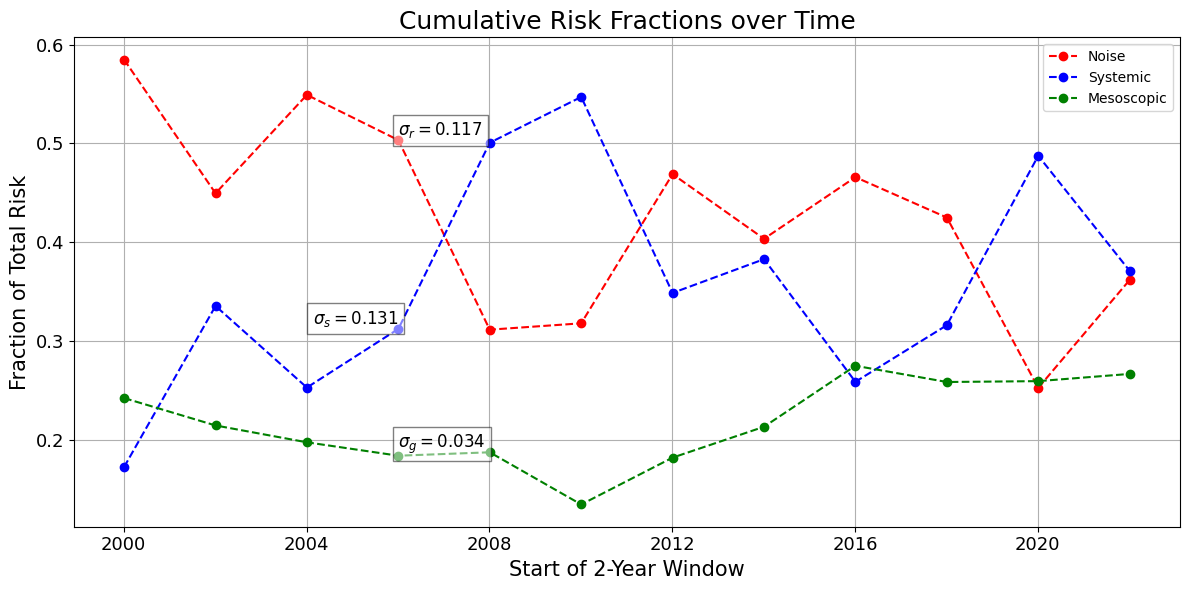

In [25]:
portfolio.plot_stability()

The mesoscopic cumulative risk fraction in quite stable between 0.15 and 0.28, with the lowest
deviation, almost four times lower than the noise and systematic component

## Community

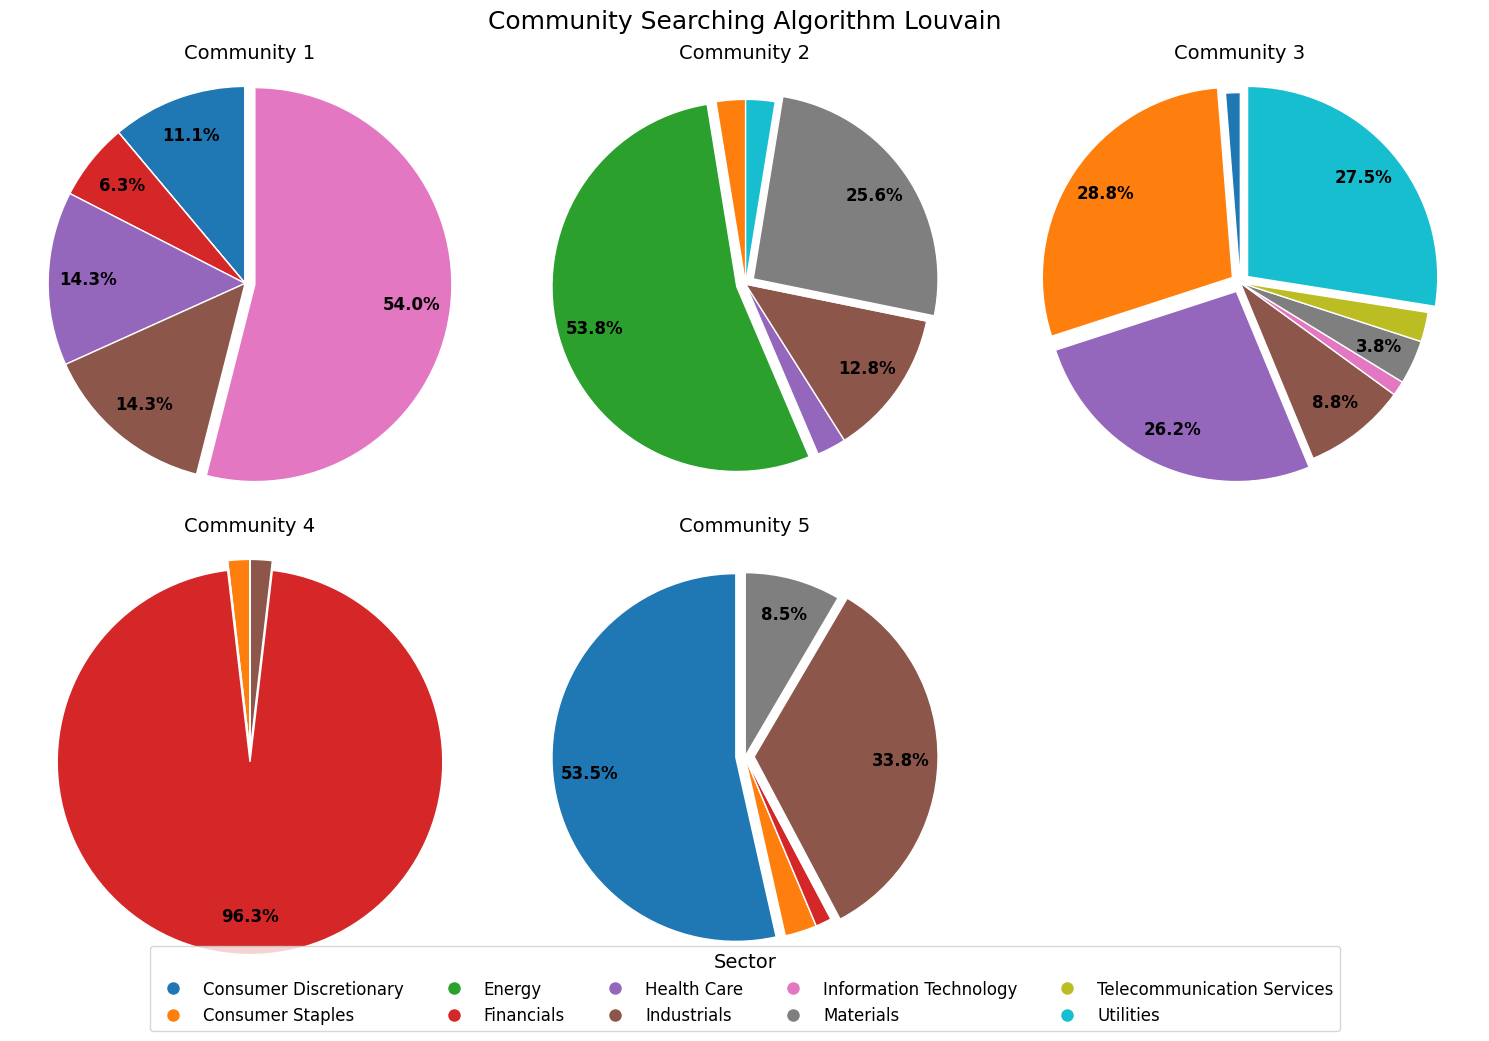

In [26]:
portfolio.mesoscopic_filter()
portfolio.community_discover(algo = "Louvain")
portfolio.plot_communities_pie(title = "Louvain")

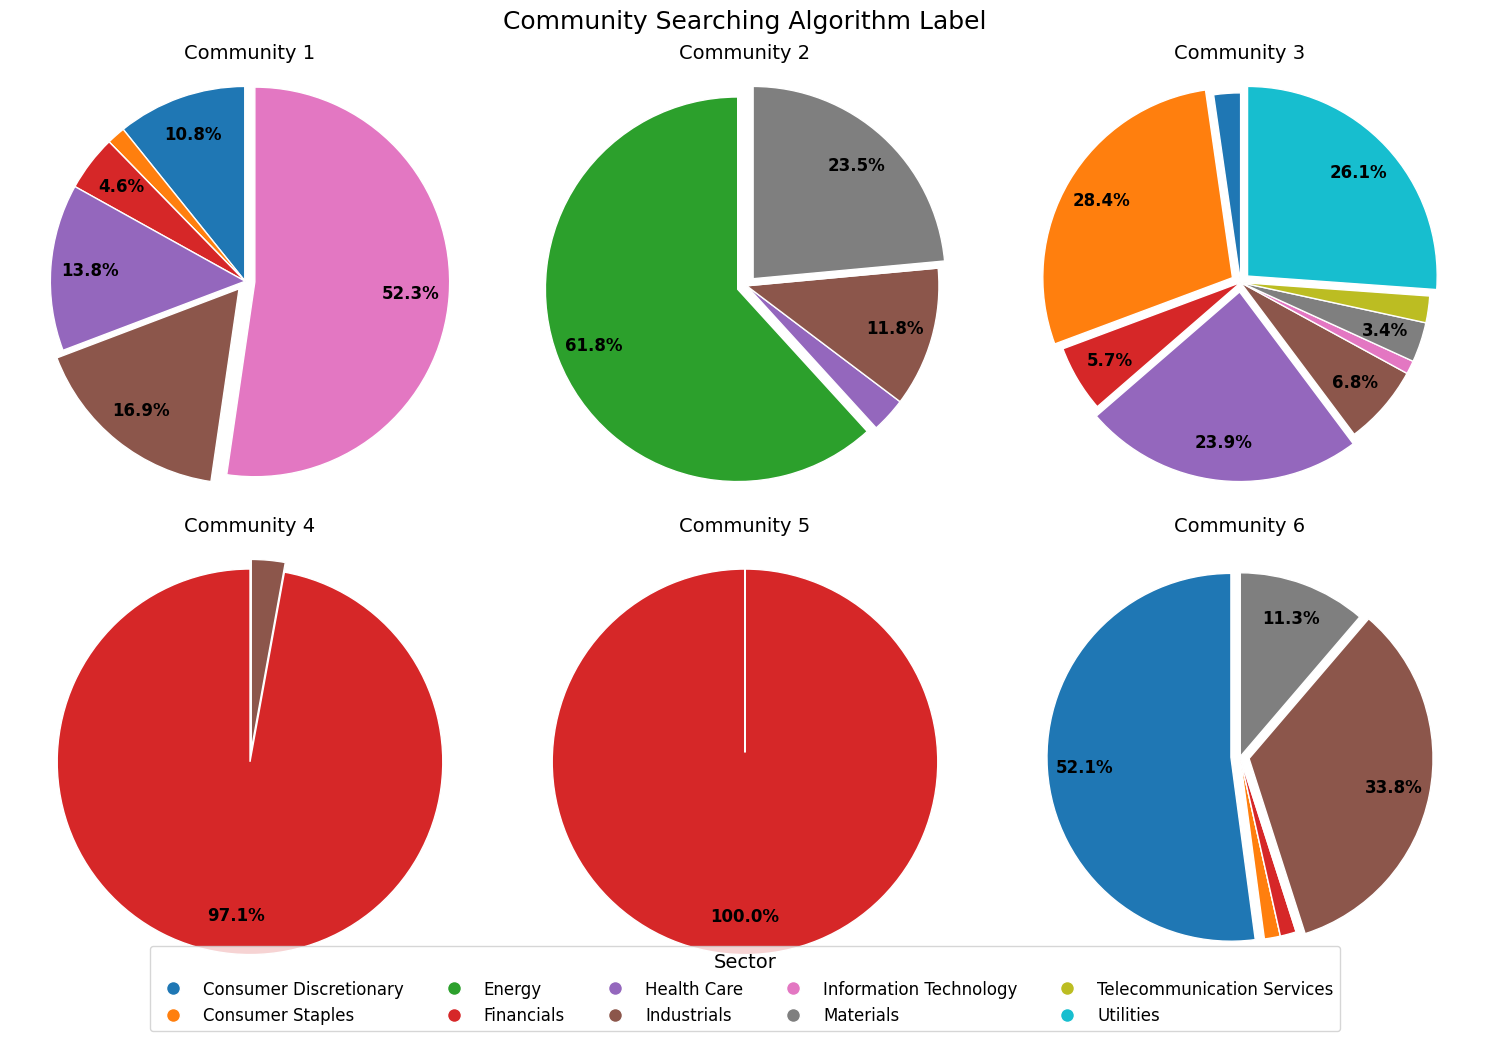

In [27]:
portfolio.mesoscopic_filter()
portfolio.community_discover(algo = "Label")
portfolio.plot_communities_pie(title = 'Label')

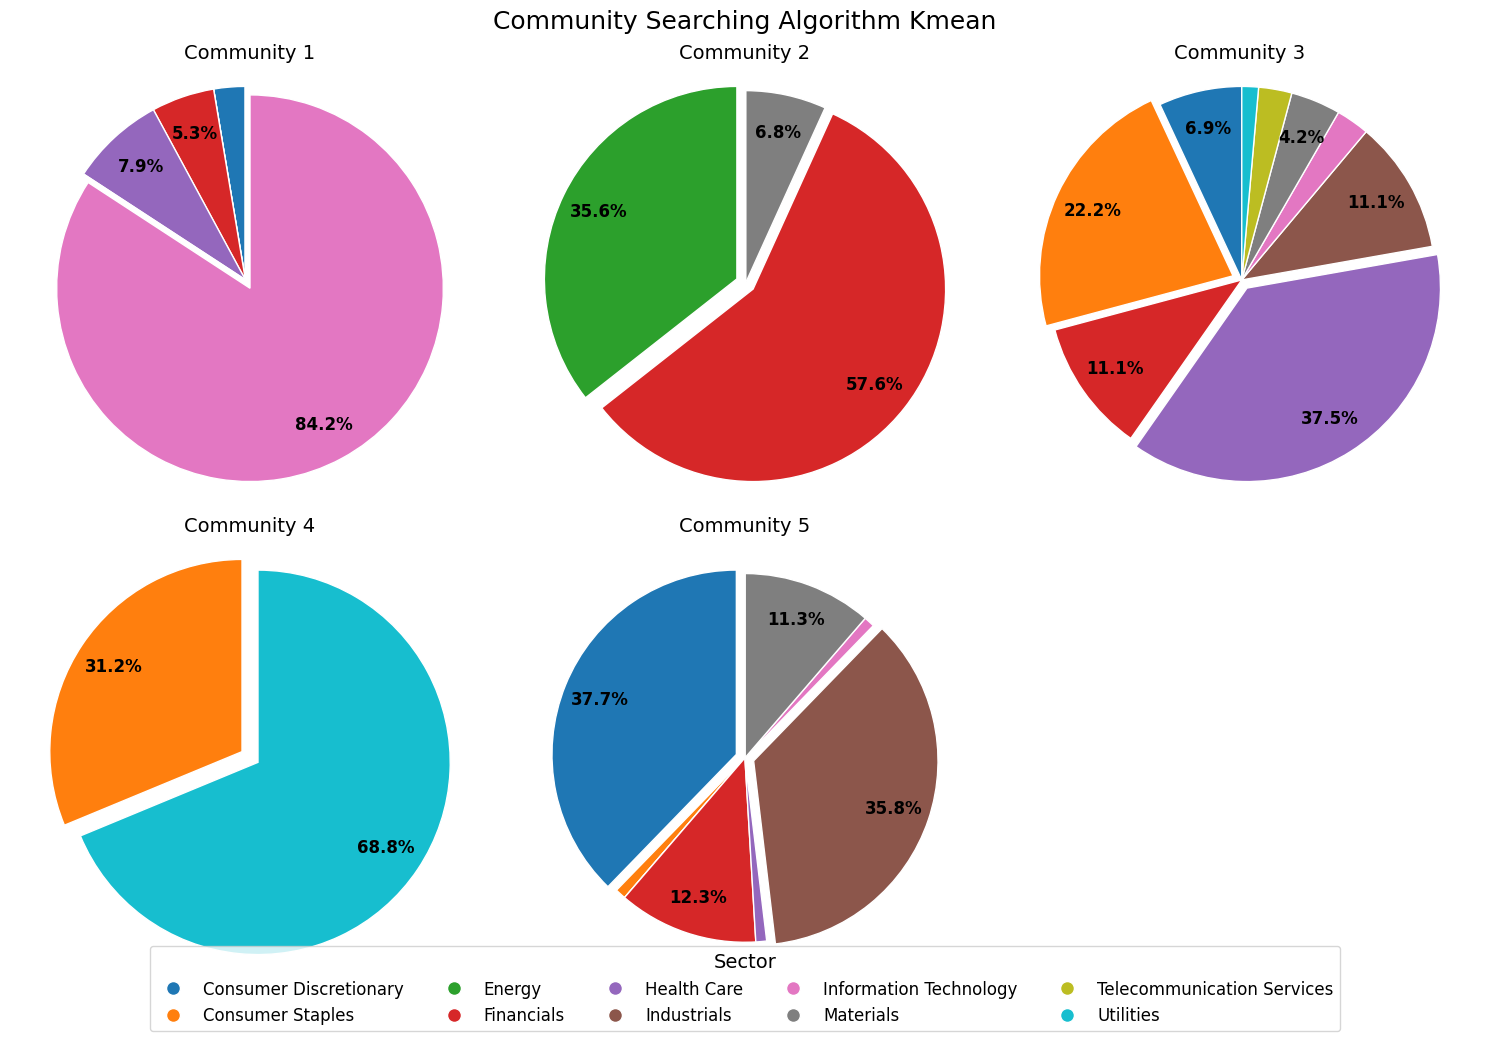

In [28]:
portfolio.mesoscopic_filter()
portfolio.community_discover(algo = "Kmean")
portfolio.plot_communities_pie(title = 'Kmean')

The community algorithms considered identify a cluster where the dominant sector is the Financial.

At the same time, while Louvain and Label Propagation Algorithm consider a more heterogeneous sector, the K-Means portfolio tends to return more homogeneous sector.

## Portfolio Building

### Weight Distribution asset

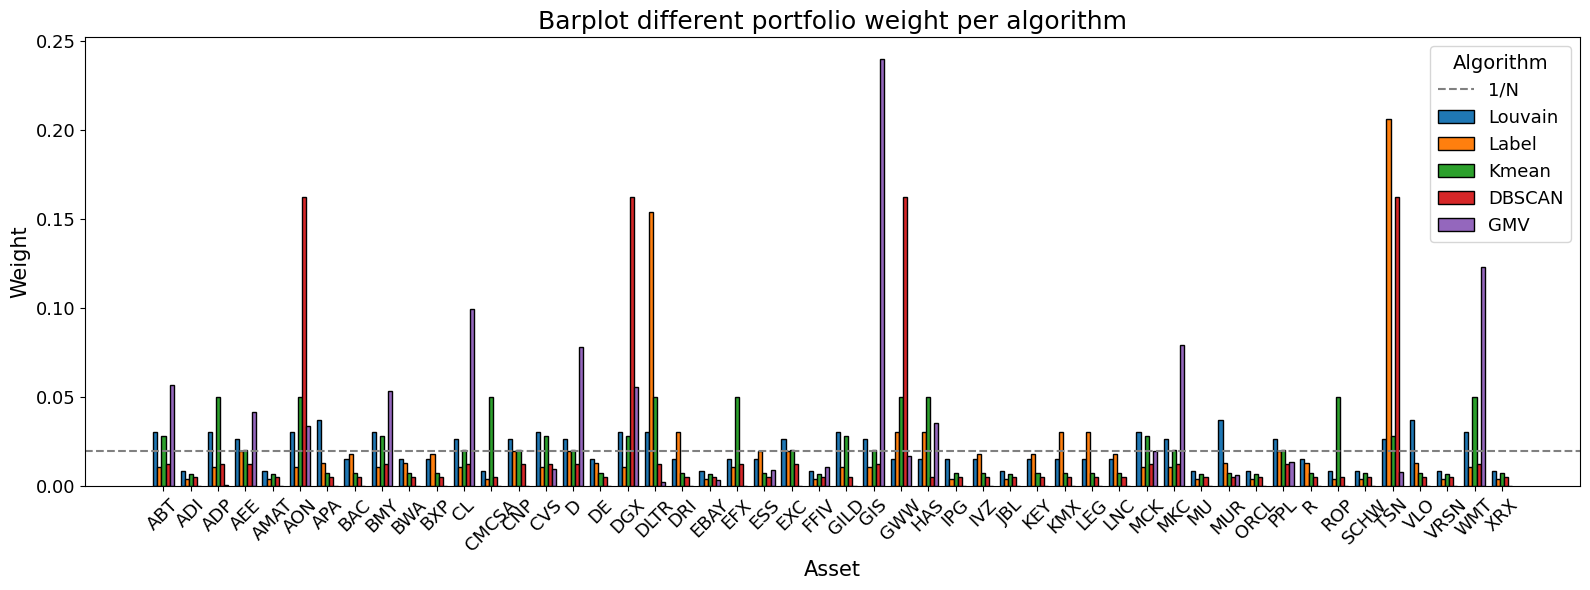

In [33]:
num_asset = 50
price_data_sampled = price_data.sample(n= num_asset, axis=1, random_state=42)
price_data_sampled = price_data_sampled[sorted(price_data_sampled.columns)]
returns = price_data_sampled.pct_change().dropna() 
portfolio = Portfolio(data_csv, price_data = price_data_sampled, returns = returns)
portfolio.C_g = portfolio.mesoscopic_filter()
weights_dict = {}

#alg_list = ["Louvain", "Label", "Kmean", "DBSCAN", "GMV"]
alg_list = ["Louvain", "Label", "Kmean", "DBSCAN"]
for alg in alg_list: 
    communities = portfolio.community_discover(algo=alg)
    weights = portfolio.portfolio_building(community=True, algo=alg)
    weights_dict[alg] = weights

weights_dict['GMV'] = portfolio.portfolio_building(community=False)
weights_df = pd.DataFrame(weights_dict, index=price_data_sampled.columns)

# Plot
labels = weights_df.index.to_list()           
algorithms = weights_df.columns.to_list()     
n_algos = len(algorithms)
x = np.arange(len(labels))                    
width = 0.15                                  

fig, ax = plt.subplots(figsize=(16, 6))
for i, algo in enumerate(algorithms):
    bar_positions = x + (i - n_algos/2) * width + width/2
    ax.bar(bar_positions, weights_df[algo], width=width, label=algo, edgecolor='black')

ax.axhline(1/num_asset, color='gray', linestyle='--', linewidth=1.5, label='1/N')
ax.set_title("Barplot different portfolio weight per algorithm", fontsize=18)
ax.set_ylabel("Weight", fontsize=15)
ax.set_xlabel("Asset", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend(title="Algorithm", fontsize = 13, title_fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13) 
plt.tight_layout()
plt.show()

Louvain and K-Means algorithm returns more diversification, Label propagation can highlight interesting sectoral hubs, while the DBSCAN can identify interesting outlier

## Back-test

In [ ]:
def fine_tuning_k_means(portfolio_train,split = 0.8, list_cluster = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], short = False, verbose = True):
    """
    Grid-search the number of KMeans clusters (mesoscopic communities) by
    maximizing out-of-sample Sharpe ratio on a simple train/validation split.

    Parameters
    ----------
    portfolio_train : Portfolio class
        Its returns are split into train and validation segments.
    split : float
        Fraction of samples to allocate to the training segment.
    list_cluster : list[int]
        Candidate numbers of clusters for KMeans community detection.
    short : bool
        If True, allow short-selling in GMV optimization. Otherwise long-only.
    verbose : bool
        If True, pretty-print Sharpe results per candidate.

    Returns
    -------
    int
        The cluster count (K) with the highest validation Sharpe ratio.
    """
    # Determine split index and slice returns into train/validation
    train_size = int(len(portfolio_train.returns) * split)
    train_df = portfolio_train.returns.iloc[:train_size]
    val_df = portfolio_train.returns.iloc[train_size:].values

    sharp_ratio = []# store Sharpe per candidate K
    for cluster in list_cluster:
        # Rebuild a Portfolio limited to the training window.
        portfolio_train = Portfolio(data_csv, price_data = portfolio_train.price_data, returns = train_df)

        # Build portfolio using KMeans over mesoscopic correlations with K=cluster
        weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'Kmean', n_clusters = cluster)
        
        # Project validation asset returns onto weights to get portfolio series
        test_returns = val_df @ weights
        
         # Annualized Sharpe: No risk-free-rate
        sharpe_ann = test_returns.mean() / test_returns.std() * np.sqrt(252)
        sharp_ratio.append(sharpe_ann)
        if verbose:
            summary_df = pd.DataFrame([
            {
                "Number Cluster": cluster,
                "Sharp Ratio": sharpe_ann,
            }
        ])
        print(tabulate(summary_df.round(4), headers='keys', tablefmt='fancy_grid'))

    # Report and return the K with the maximum Sharpe
    print(f"====== Number Cluster: {list_cluster[np.argmax(sharp_ratio)]}======")
    return list_cluster[np.argmax(sharp_ratio)]     

In [ ]:
def backtest_fun(portfolio, train_months = 36 , burn_period_month  = 6, test_months =18, model = 'Louvain', short = False, verbose = True, **kwargs):
    """
    Rolling backtest for mesoscopic / community-based GMV strategies.

    At each iteration:
      1) Split the full return panel into a TRAIN window, BURN/GAP period, and  TEST.
      2) Fit the portfolio model on TRAIN only.
      3) Evaluate out-of-sample on TEST: 

    Parameters
    ----------
    portfolio : Portfolio
        Portfolio instance with `data_csv`, and (optionally) `price_data`. 
        Returns are (re)computed internally.
    train_months : int
        Length of the in-sample training window, in months.
    burn_period_month : int
        Gap between train and test.
    test_months : int
        Length of the out-of-sample evaluation window, in months.
    model : {'Louvain','Label','Equal','GMV','Kmean','DBSCAN','Sector'}
        Strategy to fit.
    short : bool
        If True, allow short selling in the optimization.
    verbose : bool
        If True, print per-window diagnostics.
    **kwargs :
        Extra knobs (e.g., fine_tuning=True for Kmean; list_cluster=...).

    Returns
    -------
    list[dict]
        One record per rolling iteration with:
        - start / end : timestamps of the (train_end, test_end) markers
        - Reliability : |σ_test_annual - σ_pred_train_annual| / σ_pred_train_annual
        - Sharpe Ratio : annualized Sharpe on TEST
        - Number of Cluster : crude proxy printed by the chosen model branch
    """

    # Ensure returns exist and set a datetime index
    returns = portfolio.compute_return()
    returns.index = pd.to_datetime(returns.index)

    results = []
    start_idx = returns.index[0]
    current_date = start_idx

    # Iterate as long as we can place TRAIN + BURN + TEST entirely inside the sample
    while current_date + pd.DateOffset(months=train_months + burn_period_month + test_months) < returns.index[-1]:
        # TRAIN ends here
        train_end = current_date + pd.DateOffset(months=train_months)
        #TEST start after burn-in
        test_start = train_end + pd.DateOffset(months= test_months + burn_period_month)
        test_end = test_start + pd.DateOffset(months=test_months)

        # Split TRAIN and TEST
        returns_train = returns[(returns.index >= current_date) & (returns.index < train_end)]
        test_data = returns[(returns.index >= test_start) & (returns.index < test_end)]

        # Build a fresh Portfolio on TRAIN only (avoid leakage)
        portfolio_train = Portfolio(portfolio.data_csv, price_data = portfolio.price_data, returns = returns_train)

        if model == 'Louvain':
            weights = portfolio_train.portfolio_building(short = short, algo = 'Louvain')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))

        elif model == 'Label':
            weights = portfolio_train.portfolio_building(short = short, algo = 'Label')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))

        elif model == 'Equal':
            # 1/N benchmark
            weights = np.ones(len(test_data.columns)) * 1 / len(test_data.columns)
            num_cluster = None

        elif model == "GMV":
            weights = portfolio_train.portfolio_building(short = short, community = False)
            num_cluster = None

        elif model == "Kmean":
            # Optionally fine-tune K via validation Sharpe on the TRAIN set
            fine_tuning = kwargs.get('fine_tuning', False)
            if fine_tuning is True:
                list_cluster = kwargs.get('list_cluster', [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
                num_cluster = fine_tuning_k_means(portfolio_train = portfolio_train,split = 0.8, list_cluster = list_cluster , short = short)
                weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'Kmean', n_cluster = num_cluster)
                print(f"Cluster found: {num_cluster}")
            else:
                weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'Kmean')
                print(f"Cluster found: {len(np.unique(weights))}")
                num_cluster = len(np.unique(weights))

        elif model == "DBSCAN":
            weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'DBSCAN')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))

        elif model == "Sector":
            weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'Sector')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))

        else:
            raise ValueError("Select a model between (Louvain, Label, Equal, GMV, Kmean, DBASCAN, Sector)")
    
        # Portfolio returns on TEST
        test_returns = test_data @ weights

        # Predicted volatility
        sigma_p = (portfolio_train.returns@ weights).std()
        
        #Annualize (252 days)
        sharpe_ann = test_returns.mean() / test_returns.std() * np.sqrt(252)
        sigma_p_ann = sigma_p * np.sqrt(252)
        sigma_test_ann = test_returns.std() * np.sqrt(252)

        results.append({
            "start": train_end,
            "end": test_end,
            "Reliability": np.abs(sigma_test_ann - sigma_p_ann)/sigma_p_ann,
            "Sharpe Ratio": sharpe_ann,
            "Number of Cluster": num_cluster
            })
        if verbose:
            print(results[-1])
        
        #next loop
        current_date = current_date + pd.DateOffset(months = train_months)
    return results

In [ ]:
def plot_results_backtest(results, method_labels, markers,colors):
    """
    Plot rolling backtest results (Sharpe, Reliability, Num. Clusters) for multiple models.

    Parameters
    ----------
    results : return of beck_test
    method_labels : dict[str, str]
        Mapping model_name -> pretty label for legend.
    markers : dict[str, str]
        Mapping model_name -> matplotlib marker style (e.g., 'o', 's', '^').
    colors : dict[str, str]
        Mapping model_name -> color hex or named color.

    Returns
    -------
    pandas.DataFrame
        Summary table with average metrics per model (printed and returned).
    """

    # Convert lists of dicts into per-model DataFrames
    dfs = {model: pd.DataFrame(data) for model, data in results.items()}

    # Plot each metric in its own figure
    for metric in ['Sharpe Ratio', 'Reliability', 'Number of Cluster']:
        fig, ax = plt.subplots(figsize=(16, 8))
        for model, df in dfs.items():
            ax.plot(
                df['end'], df[metric],
                marker=markers[model],
                linestyle='-.',
                color=colors[model],
                label=method_labels[model]
            )

        # Use Louvain's 'end' dates as the common tick positions and labels
        ax.set_xticks(dfs["Louvain"]['end'])
        ax.set_xticklabels(dfs["Louvain"]['end'].dt.strftime('%Y-%m-%d'), rotation=45, ha='right')
        ax.set_title(f"{metric} Comparison Test", size = 18)
        ax.set_xlabel("End Test Date", size = 15)
        ax.set_ylabel(f"Annualized - {metric}", size = 15)
        ax.grid()
        ax.legend(title = 'Algorithm', fontsize = 13, title_fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=13)  
        ax.tick_params(axis='both', which='minor', labelsize=13)
        plt.tight_layout()
        plt.show()

    # Build a summary table (simple averages across the rolling windows)
    summary_df = pd.DataFrame([
        {
            "Method": method_labels[model],
            "Average Sharpe Ratio ": dfs[model]['Sharpe Ratio'].mean(),
            "Average Reliability": dfs[model]['Reliability'].mean(),
            "Average Number of Cluster": dfs[model]['Number of Cluster'].mean()
        }
        for model in dfs
    ])

    print(tabulate(summary_df.round(4), headers='keys', tablefmt='fancy_grid'))
    return summary_df

### Fine-Tuning

In [ ]:
model = ["Louvain", "Label","Kmean","DBSCAN", "Sector","GMV", "Equal"]
results = {}
for m in model:
    print(f"====== Start {m} ======")
    portfolio = Portfolio(data_csv, price_data = price_data)
    results[f"{m}"] = backtest_fun(portfolio, train_months = 36 , burn_period_month  = 6, test_months = 18, model = m, short = False, verbose = True, fine_tuning = True)

method_labels = {
        "Louvain": "Mesoscopic community - Louvain",
        "Label": "Mesoscopic community - Label",
        "Kmean": "Mesoscopic community - Kmean",
        "DBSCAN": "Mesoscopic community - DBSCAN",
        "Sector": "Sector community",
        "GMV": "GMV",
        "Equal": "1/N"
    }

markers = {
        "Louvain": "*",
        "Label": "D",
        "Kmean": "s",
        "DBSCAN": "<",
        "Sector": "^",
        "GMV": "p",
        "Equal": "X"
    }

colors = {
        "Louvain": "red",
        "Label": "purple",
        "Kmean": "black",
        "DBSCAN": "orange",
        "Sector": "grey",
        "GMV": "blue",
        "Equal": "green"
    }

====== Start Louvain ======
Cluster found: 5
{'start': Timestamp('2003-01-04 00:00:00'), 'end': Timestamp('2006-07-04 00:00:00'), 'Reliability': np.float64(0.011448399088532586), 'Sharpe Ratio': np.float64(1.5754173603329331), 'Number of Cluster': 5}
Cluster found: 5
{'start': Timestamp('2006-01-04 00:00:00'), 'end': Timestamp('2009-07-04 00:00:00'), 'Reliability': np.float64(2.4661533008963965), 'Sharpe Ratio': np.float64(-0.11922741336279012), 'Number of Cluster': 5}
Cluster found: 3
{'start': Timestamp('2009-01-04 00:00:00'), 'end': Timestamp('2012-07-04 00:00:00'), 'Reliability': np.float64(0.1937957059618682), 'Sharpe Ratio': np.float64(0.6281738588817639), 'Number of Cluster': 3}
Cluster found: 4
{'start': Timestamp('2012-01-04 00:00:00'), 'end': Timestamp('2015-07-04 00:00:00'), 'Reliability': np.float64(0.5208611949353257), 'Sharpe Ratio': np.float64(0.9265241270573635), 'Number of Cluster': 4}
Cluster found: 5
{'start': Timestamp('2015-01-04 00:00:00'), 'end': Timestamp('2018-

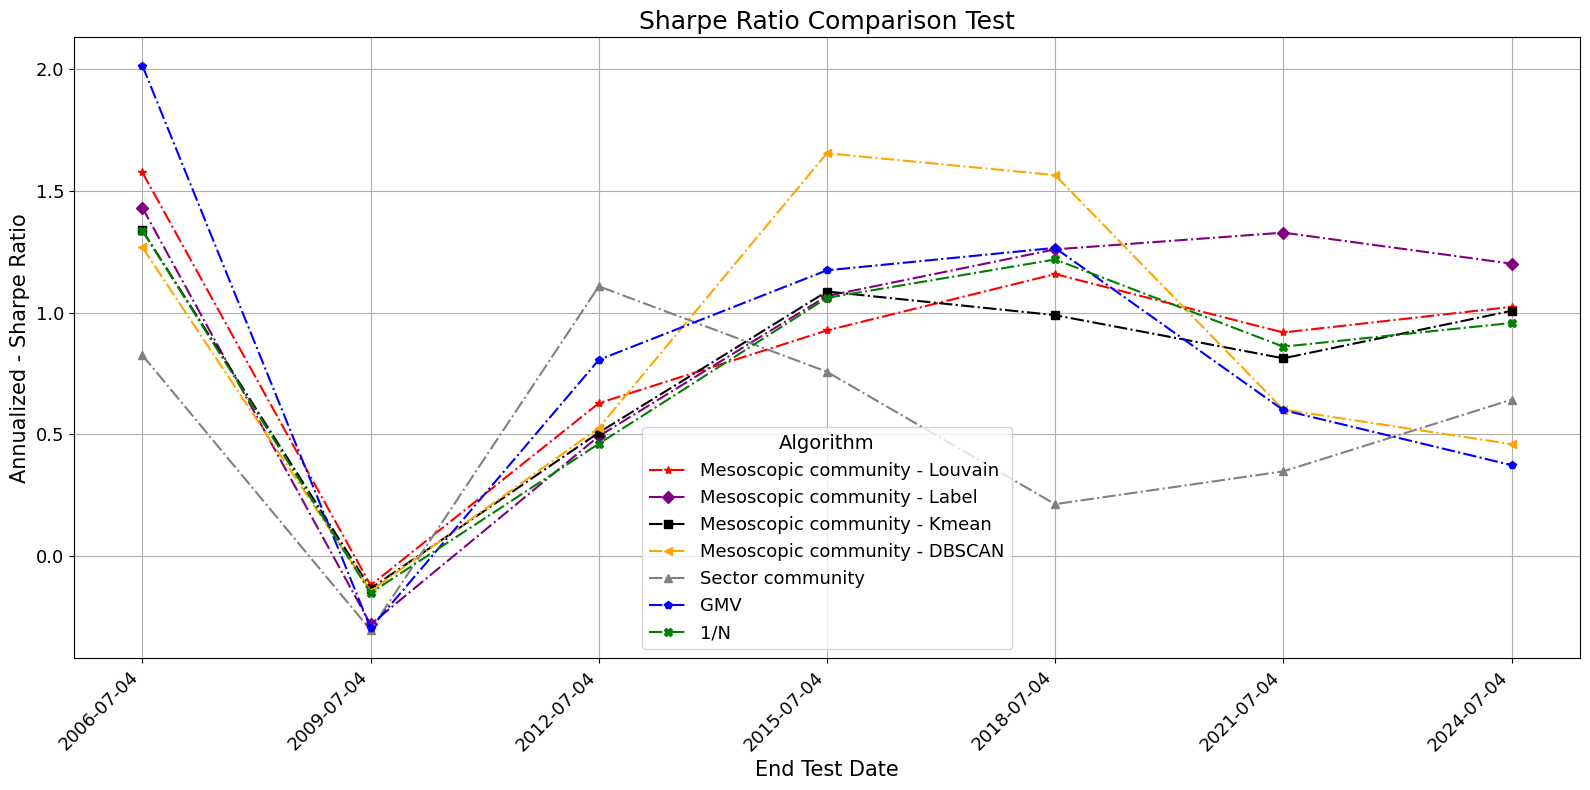

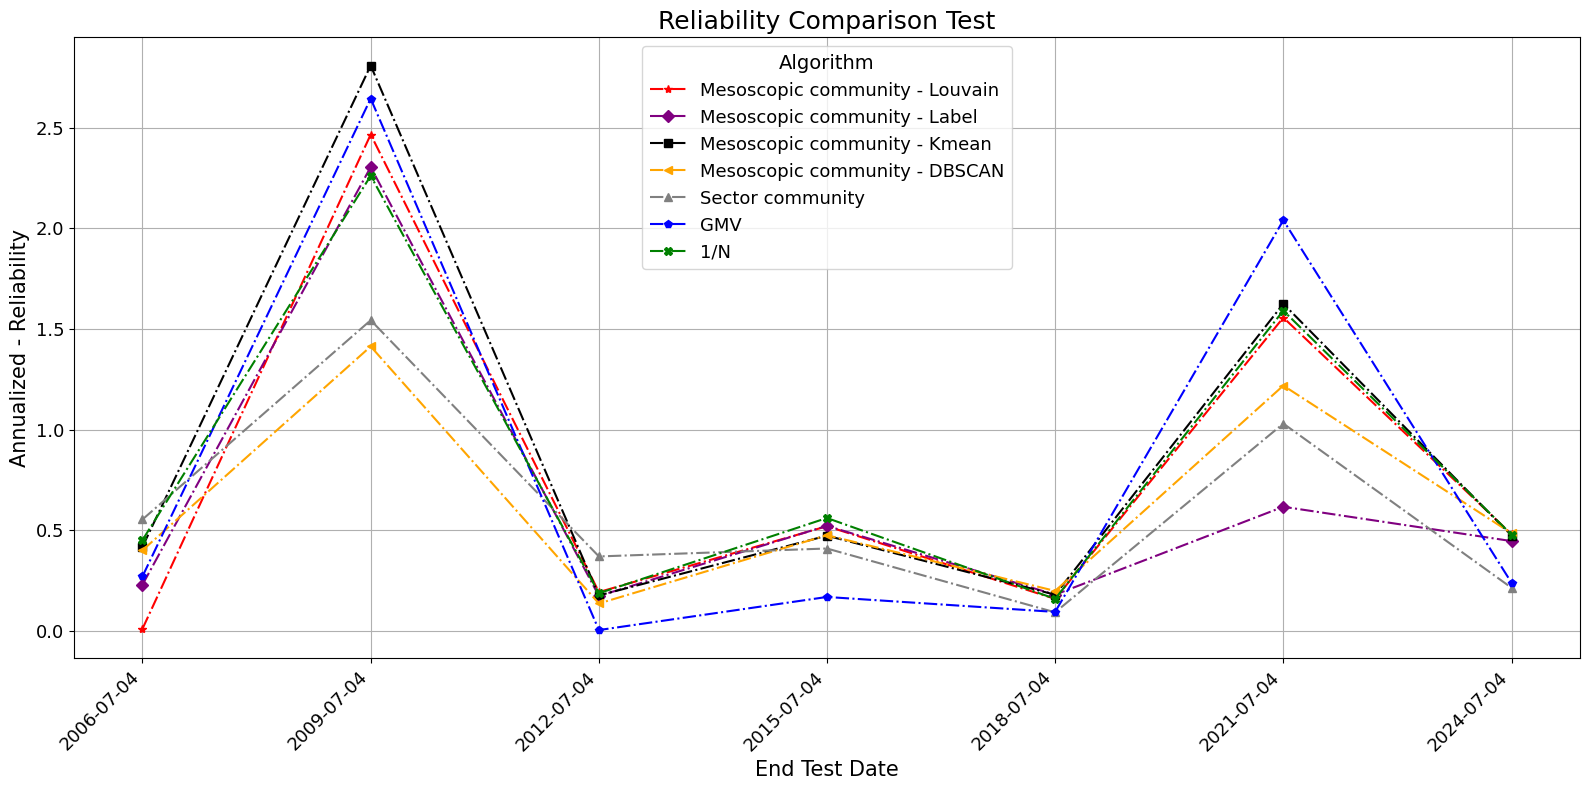

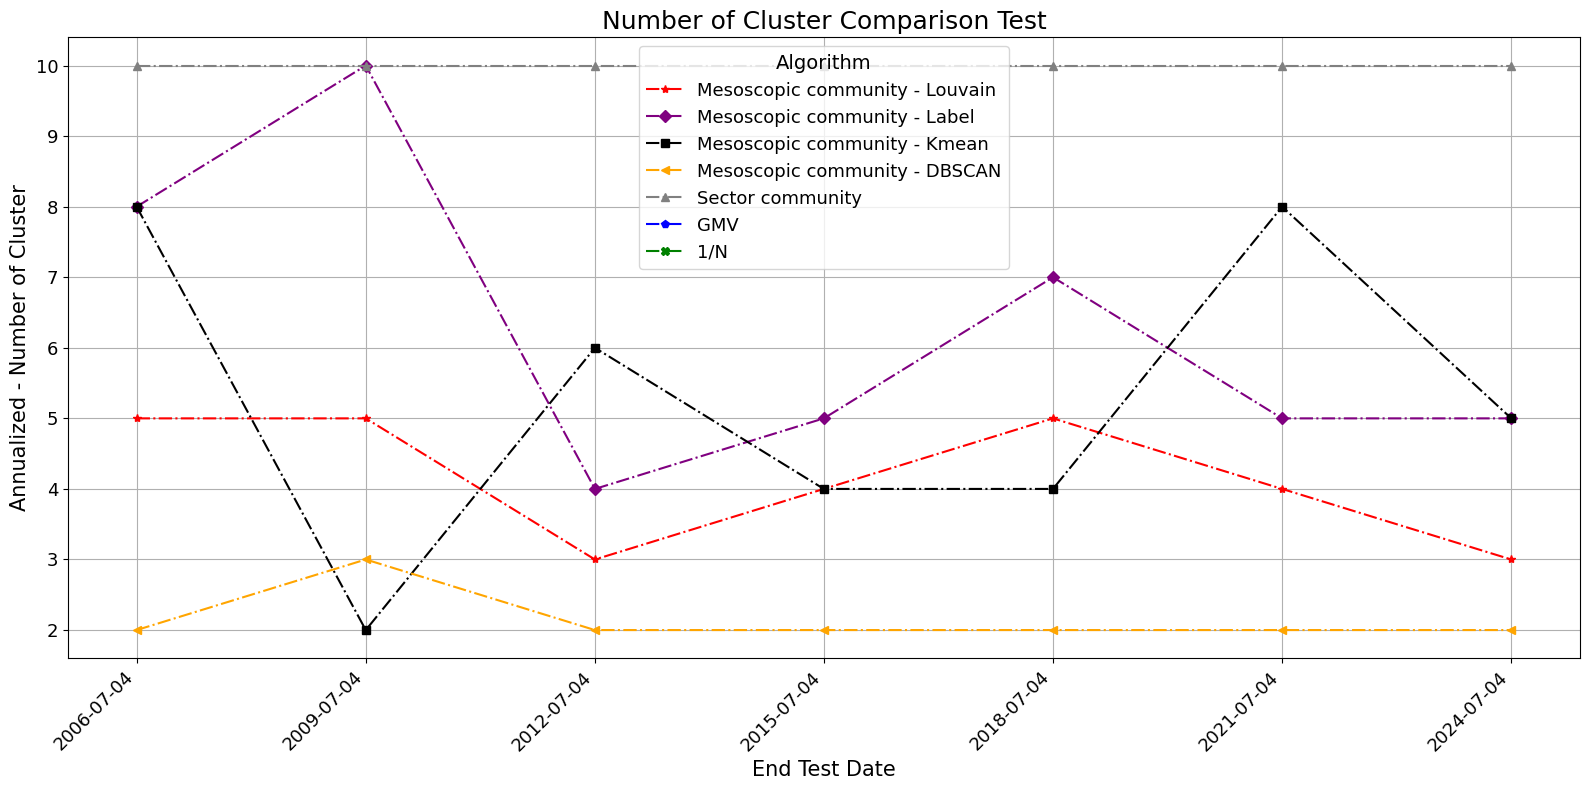

╒════╤════════════════════════════════╤═════════════════════════╤═══════════════════════╤═════════════════════════════╕
│    │ Method                         │   Average Sharpe Ratio  │   Average Reliability │   Average Number of Cluster │
╞════╪════════════════════════════════╪═════════════════════════╪═══════════════════════╪═════════════════════════════╡
│  0 │ Mesoscopic community - Louvain │                  0.8729 │                0.7701 │                      4.1429 │
├────┼────────────────────────────────┼─────────────────────────┼───────────────────────┼─────────────────────────────┤
│  1 │ Mesoscopic community - Label   │                  0.9284 │                0.6397 │                      6.2857 │
├────┼────────────────────────────────┼─────────────────────────┼───────────────────────┼─────────────────────────────┤
│  2 │ Mesoscopic community - Kmean   │                  0.801  │                0.8799 │                      5.2857 │
├────┼────────────────────────────────┼─

In [45]:
summary_df = plot_results_backtest(results, method_labels, markers, colors)

In [41]:
model = ["Louvain", "Label", "Kmean", "DBSCAN", "Sector","GMV", "Equal"]
results_short = {}
for m in model:
    print(f"====== Start {m} ======")
    portfolio = Portfolio(data_csv, price_data = price_data)
    results_short[f"{m}"] = backtest_fun(portfolio, train_months = 36 , burn_period_month  = 6, test_months =18, model = m, short = True, verbose = True, fine_tuning = True)
method_labels = {
        "Louvain": "Mesoscopic community - Louvain",
        "Label": "Mesoscopic community - Label",
        "Kmean": "Mesoscopic community - Kmean",
        "DBSCAN": "Mesoscopic community - DBSCAN",
        "Sector": "Sector community",
        "GMV": "GMV",
        "Equal": "1/N"
    }

markers = {
        "Louvain": "*",
        "Label": "D",
        "Kmean": "s",
        "DBSCAN": "<",
        "Sector": "^",
        "GMV": "p",
        "Equal": "X"
    }

colors = {
        "Louvain": "red",
        "Label": "purple",
        "Kmean": "black",
        "DBSCAN": "orange",
        "Sector": "grey",
        "GMV": "blue",
        "Equal": "green"
    }

====== Start Louvain ======
Cluster found: 5
{'start': Timestamp('2003-01-04 00:00:00'), 'end': Timestamp('2006-07-04 00:00:00'), 'Reliability': np.float64(0.011448399088532586), 'Sharpe Ratio': np.float64(1.5754173603329331), 'Number of Cluster': 5}
Cluster found: 5
{'start': Timestamp('2006-01-04 00:00:00'), 'end': Timestamp('2009-07-04 00:00:00'), 'Reliability': np.float64(2.4661533008963965), 'Sharpe Ratio': np.float64(-0.11922741336279012), 'Number of Cluster': 5}
Cluster found: 3
{'start': Timestamp('2009-01-04 00:00:00'), 'end': Timestamp('2012-07-04 00:00:00'), 'Reliability': np.float64(0.1937957059618682), 'Sharpe Ratio': np.float64(0.6281738588817639), 'Number of Cluster': 3}
Cluster found: 4
{'start': Timestamp('2012-01-04 00:00:00'), 'end': Timestamp('2015-07-04 00:00:00'), 'Reliability': np.float64(0.5208611949353257), 'Sharpe Ratio': np.float64(0.9265241270573635), 'Number of Cluster': 4}
Cluster found: 5
{'start': Timestamp('2015-01-04 00:00:00'), 'end': Timestamp('2018-

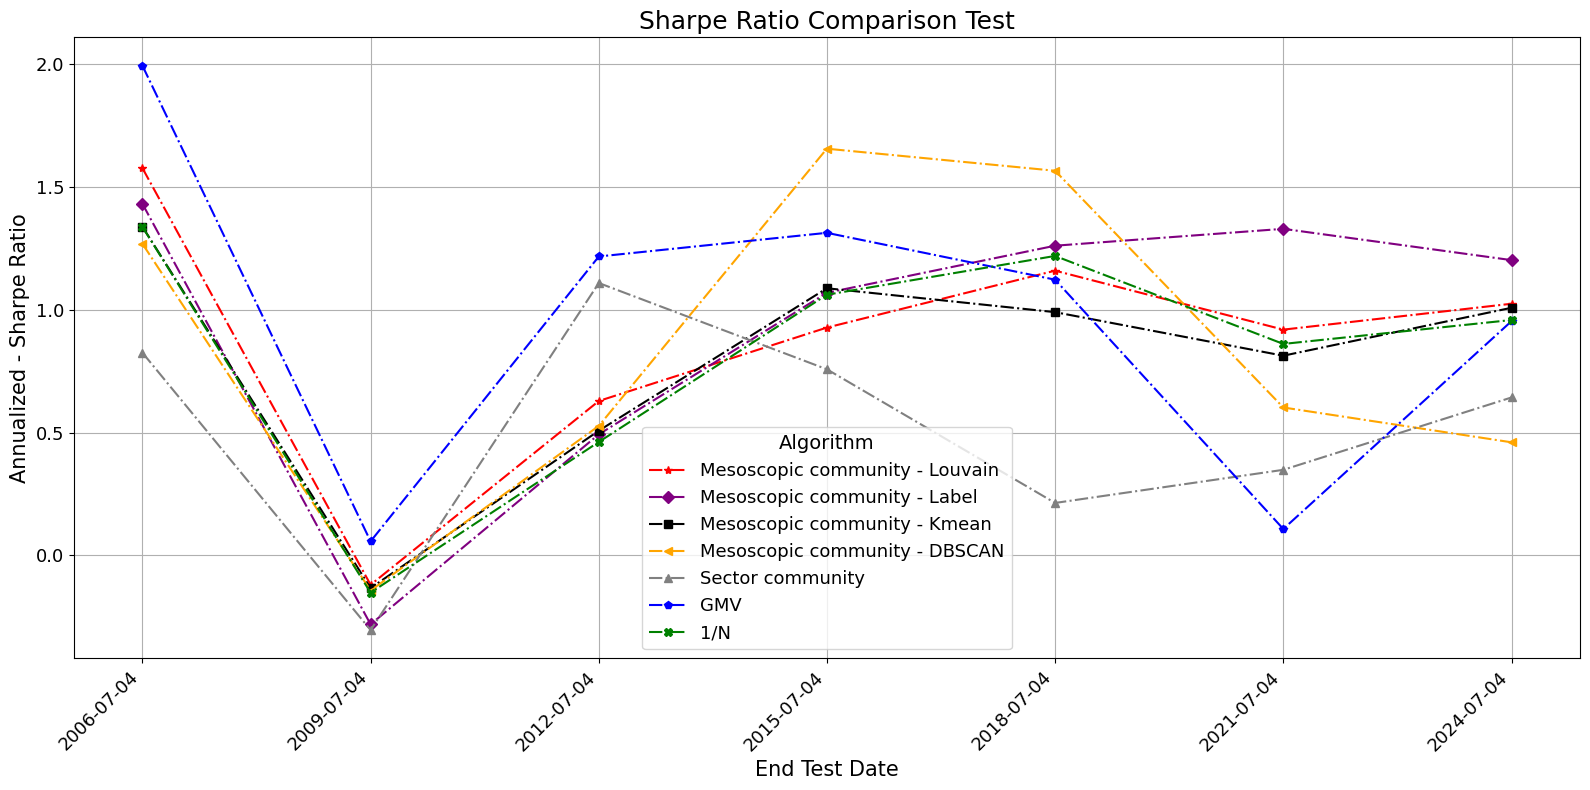

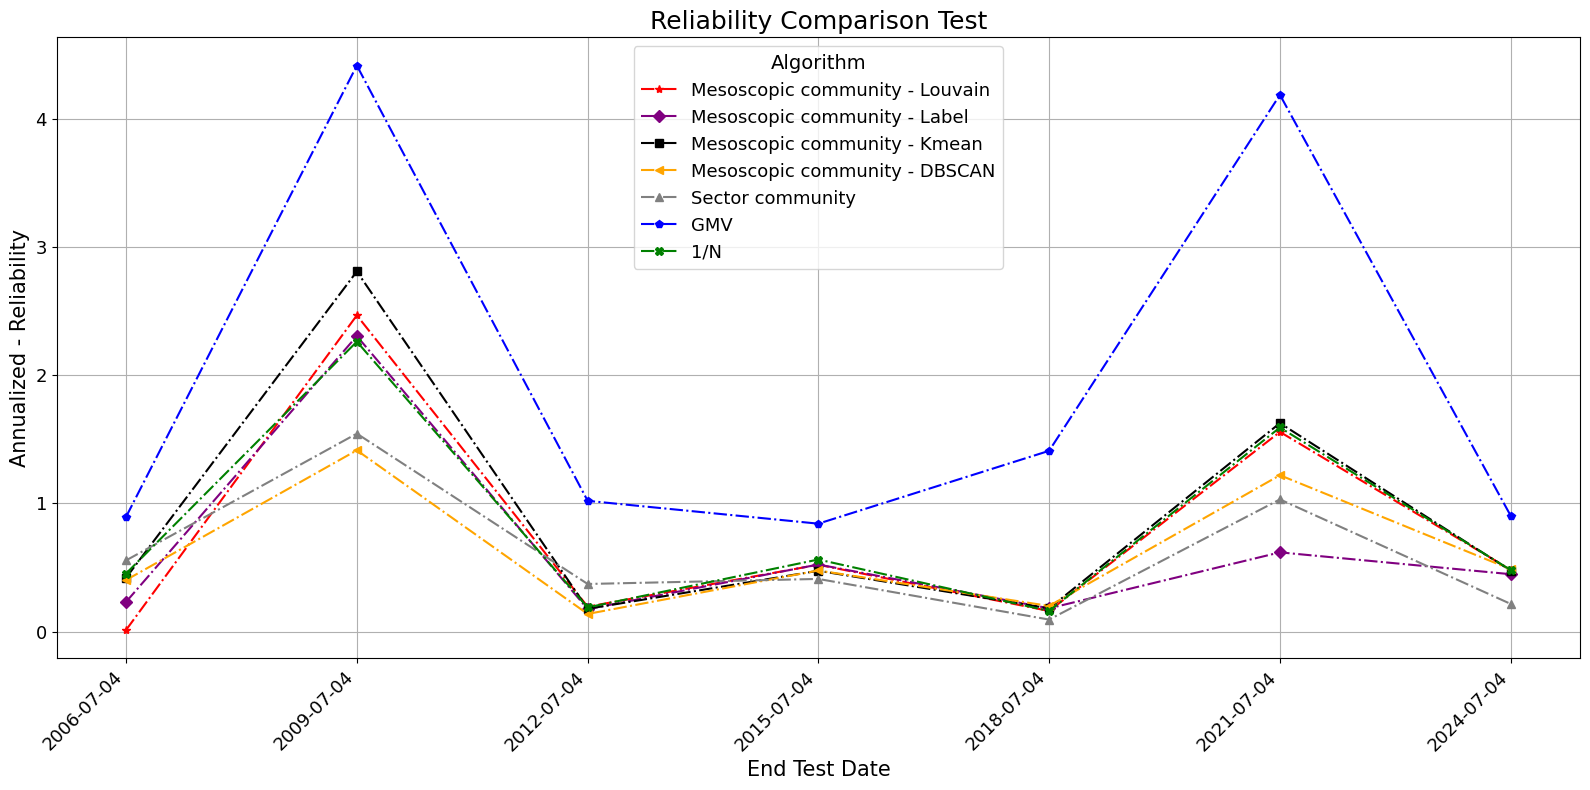

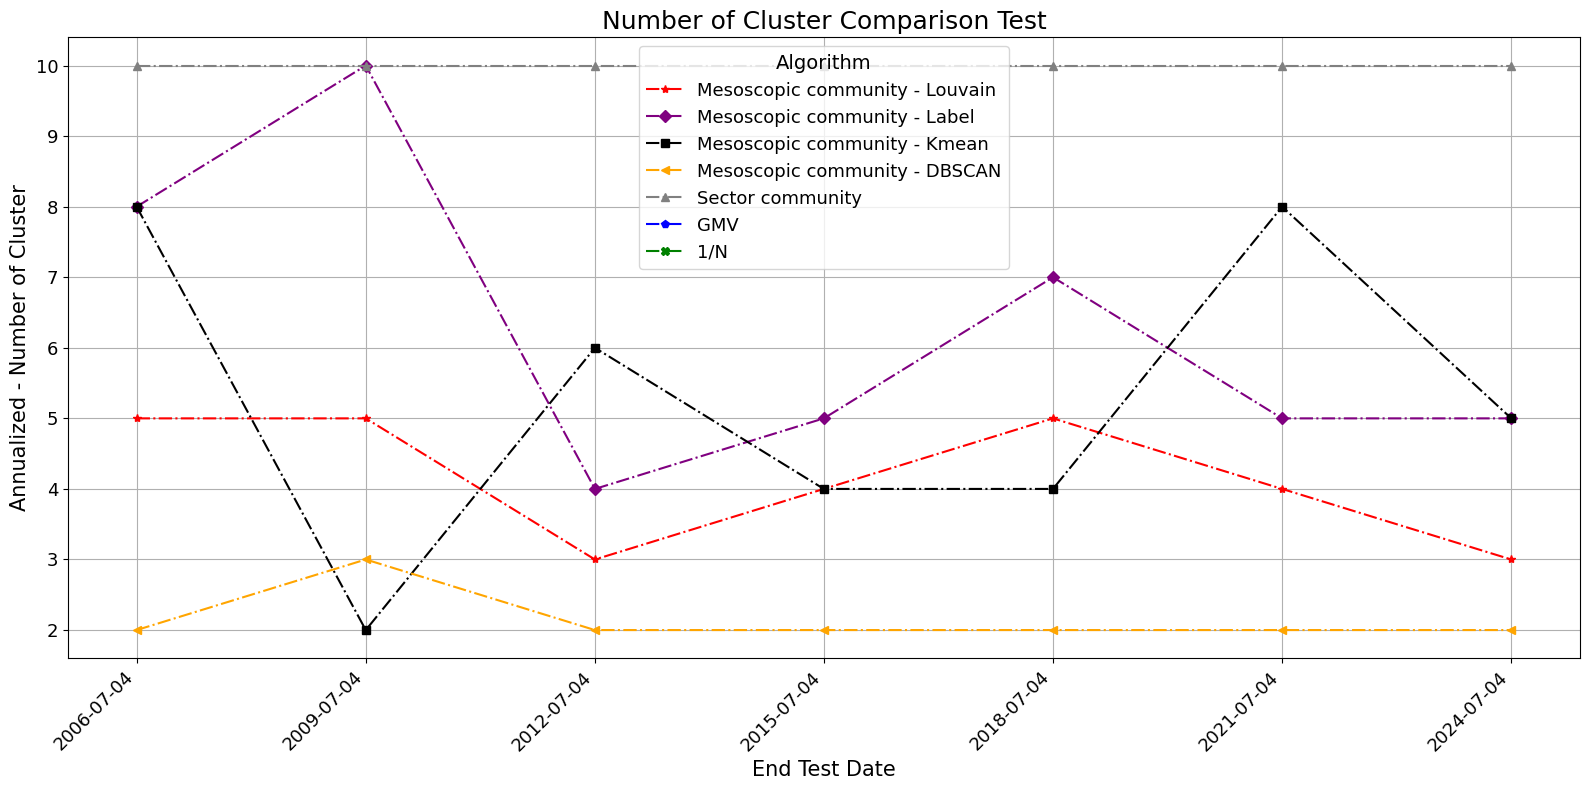

╒════╤════════════════════════════════╤═════════════════════════╤═══════════════════════╤═════════════════════════════╕
│    │ Method                         │   Average Sharpe Ratio  │   Average Reliability │   Average Number of Cluster │
╞════╪════════════════════════════════╪═════════════════════════╪═══════════════════════╪═════════════════════════════╡
│  0 │ Mesoscopic community - Louvain │                  0.8729 │                0.7701 │                      4.1429 │
├────┼────────────────────────────────┼─────────────────────────┼───────────────────────┼─────────────────────────────┤
│  1 │ Mesoscopic community - Label   │                  0.9284 │                0.6397 │                      6.2857 │
├────┼────────────────────────────────┼─────────────────────────┼───────────────────────┼─────────────────────────────┤
│  2 │ Mesoscopic community - Kmean   │                  0.801  │                0.8799 │                      5.2857 │
├────┼────────────────────────────────┼─

In [44]:
summary_df_short = plot_results_backtest(results_short, method_labels, markers, colors)

## Drafts

In [ ]:
def backtest_fun(portfolio, train_months = 36 , burn_period_month  = 6, test_months =18, model = 'Louvain', short = False, verbose = True):
    returns = portfolio.compute_return()
    returns.index = pd.to_datetime(returns.index)
    results = []
    start_idx = returns.index[0]
    current_date = start_idx
    while current_date + pd.DateOffset(months=train_months + burn_period_month + test_months) < returns.index[-1]:
        train_end = current_date + pd.DateOffset(months=train_months)
        test_start = train_end + pd.DateOffset(months= test_months + burn_period_month)
        test_end = test_start + pd.DateOffset(months=test_months)
        returns_train = returns[(returns.index >= current_date) & (returns.index < train_end)]
        test_data = returns[(returns.index >= test_start) & (returns.index < test_end)]
        portfolio_train = Portfolio(data_csv, price_data = price_data, returns = returns_train)
        if model == 'Louvain':
            weights = portfolio_train.portfolio_building(short = short, algo = 'Louvain')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))
        elif model == 'Label':
            weights = portfolio_train.portfolio_building(short = short, algo = 'Label')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))
        elif model == 'Equal':
            weights = np.ones(len(test_data.columns)) * 1 / len(test_data.columns)
            num_cluster = None
        elif model == "GMV":
            weights = portfolio_train.portfolio_building(short = short, community = short)
            num_cluster = None
        elif model == "Kmean":
            weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'Kmean')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))
        elif model == "DBSCAN":
            weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'DBSCAN')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))
        elif model == "Sector":
            weights = portfolio_train.portfolio_building(short = short, community = True, algo = 'Sector')
            print(f"Cluster found: {len(np.unique(weights))}")
            num_cluster = len(np.unique(weights))
        else:
            raise ValueError("Select a model between (Louvain, Label, Equal, GMV, Kmean, DBASCAN, Sector)")
        test_returns = test_data @ weights
        sigma_p = (portfolio_train.returns@ weights).std()
        sharpe_ann = test_returns.mean() / test_returns.std() * np.sqrt(252)
        sigma_p_ann = sigma_p * np.sqrt(252)
        sigma_test_ann = test_returns.std() * np.sqrt(252)
        results.append({
            "start": train_end,
            "end": test_end,
            "Reliability": np.abs(sigma_test_ann - sigma_p_ann)/sigma_p_ann,
            "Sharpe Ratio": sharpe_ann,
            "Number of Cluster": num_cluster
            })
        if verbose:
            print(results[-1])
        current_date = current_date + pd.DateOffset(months = train_months)
    return results


In [ ]:
portfolio = Portfolio(data_csv, price_data = price_data)
weights = portfolio.portfolio_building(short = True, community = True, algo = 'Sector')

In [ ]:
def plot_results_backtest(results, method_labels, markers,colors):
    dfs = {model: pd.DataFrame(data) for model, data in results.items()}

    for metric in ['Sharpe Ratio', 'Reliability', 'Number of Cluster']:
        fig, ax = plt.subplots(figsize=(16, 8))
        for model, df in dfs.items():
            ax.plot(
                df['end'], df[metric],
                marker=markers[model],
                linestyle='-.',
                color=colors[model],
                label=method_labels[model]
            )

        ax.set_xticks(dfs["Louvain"]['end'])
        ax.set_xticklabels(dfs["Louvain"]['end'].dt.strftime('%Y-%m-%d'), rotation=45, ha='right')
        ax.set_title(f"{metric} Comparison Test")
        ax.set_xlabel("End Test Date")
        ax.set_ylabel(f"Annualized - {metric}")
        ax.grid()
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Summary Table
    summary_df = pd.DataFrame([
        {
            "Method": method_labels[model],
            "Average Sharpe Ratio ": dfs[model]['Sharpe Ratio'].mean(),
            "Average Reliability": dfs[model]['Reliability'].mean(),
            "Average Number of Cluster": dfs[model]['Number of Cluster'].mean()
        }
        for model in dfs
    ])

    print(tabulate(summary_df.round(4), headers='keys', tablefmt='fancy_grid'))
    return summary_df

In [ ]:
model = ["Louvain", "Label", "Kmean", "DBSCAN", "Sector","GMV", "Equal"]
results = {}
for m in model:
    print(f"====== Start {m} ======")
    portfolio = Portfolio(data_csv, price_data = price_data)
    results[f"{m}"] = backtest_fun(portfolio, train_months = 36 , burn_period_month  = 6, test_months =18, model = m, short = False, verbose = True)

In [ ]:
method_labels = {
        "Louvain": "Mesoscopic community - Louvain",
        "Label": "Mesoscopic community - Label",
        "Kmean": "Mesoscopic community - Kmean",
        "DBSCAN": "Mesoscopic community - DBSCAN",
        "Sector": "Sector community",
        "GMV": "GMV",
        "Equal": "1/N"
    }

markers = {
        "Louvain": "*",
        "Label": "D",
        "Kmean": "s",
        "DBSCAN": "<",
        "Sector": "^",
        "GMV": "p",
        "Equal": "X"
    }

colors = {
        "Louvain": "red",
        "Label": "purple",
        "Kmean": "black",
        "DBSCAN": "orange",
        "Sector": "grey",
        "GMV": "blue",
        "Equal": "green"
    }

summary_df = plot_results_backtest(results, method_labels, markers, colors)


In [ ]:
model = ["Louvain", "Label", "Kmean", "DBSCAN", "Sector","GMV", "Equal"]
results_short = {}
for m in model:
    print(f"====== Start {m} ======")
    portfolio = Portfolio(data_csv, price_data = price_data)
    results_short[f"{m}"] = backtest_fun(portfolio, train_months = 36 , burn_period_month  = 6, test_months =18, model = m, short = True, verbose = True)

In [ ]:
method_labels = {
        "Louvain": "Mesoscopic community - Louvain",
        "Label": "Mesoscopic community - Label",
        "Kmean": "Mesoscopic community - Kmean",
        "DBSCAN": "Mesoscopic community - DBSCAN",
        "Sector": "Sector community",
        "GMV": "GMV",
        "Equal": "1/N"
    }

markers = {
        "Louvain": "*",
        "Label": "D",
        "Kmean": "s",
        "DBSCAN": "<",
        "Sector": "^",
        "GMV": "p",
        "Equal": "X"
    }

colors = {
        "Louvain": "red",
        "Label": "purple",
        "Kmean": "black",
        "DBSCAN": "orange",
        "Sector": "grey",
        "GMV": "blue",
        "Equal": "green"
    }

summary_df_short = plot_results_backtest(results_short, method_labels, markers, colors)